In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from setup import *
from plts_funcs import *

## corrugation modes model

$\omega = m \Omega_{\phi} - j^{1/2} \Omega_\theta$

calcolate a $r_{ivr} = r + cs (a^{-1/3} -1)$, 
con cs costante che dipende dalla velocità del suono

In [2]:
def ivr(r, a, cs=0.17):
    r = np.asarray(r)
    a = np.asarray(a)
    cs = np.asarray(cs)
    return r + cs * (a**(-1/3) - 1)

def c_frq(m, j, a, rin, M=M_BH, cs=0.17):
    rin = np.asarray(rin)
    a = np.asarray(a)
    M = np.asarray(M)
    j = np.asarray(j)
    m = np.asarray(m)
    cs = np.asarray(cs)
    
    r_ivr = ivr(rin, a, cs)
    return m * nu_phi(r_ivr, a, M) - np.sqrt(j) * nu_theta(r_ivr, a, M)

### 1 - costante fissata, r_in fissato a isco

In [3]:
params = {
    "m": (1, 5, 5),
    "j": (1, 5, 5),
    "a": (-0.99, 0.99, 199),
    "M": (10**6, 10**7, 11),
    "cs": (0.17, 0.3, 1)
}
labels = list(params.keys())
param_vectors, mesh_arrays = create_param_grid(params)

m, j, A, M, cs = mesh_arrays

RIN = r_isco(A) 

In [4]:
freq = c_frq(m, j, A, RIN, M, cs)

/tmp/ipykernel_13124/2931491819.py:5: RuntimeWarning: divide by zero encountered in power
  return r + cs * (a**(-1/3) - 1)
/tmp/ipykernel_13124/2931491819.py:5: RuntimeWarning: invalid value encountered in power
  return r + cs * (a**(-1/3) - 1)


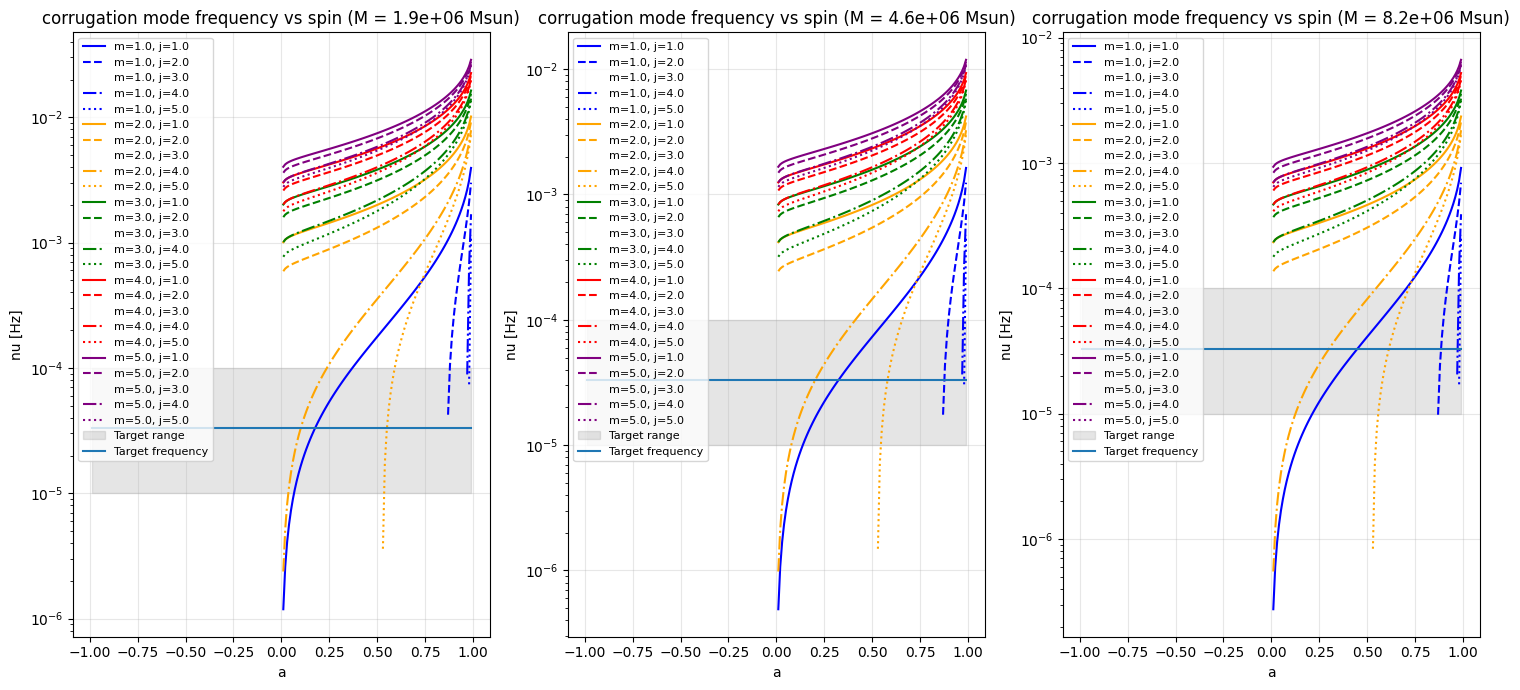

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
axes = axes.flatten()

M_idx = [1, 4, 8]
a_vals = A[0,0,:,0,0]

stiles = ['-', '--', '', '-.', ':']
colors = ["blue", "orange", "green", "red", "purple"]

# Loop over zeta values
for i, iM in enumerate(M_idx):
    for im, mm in enumerate(m):
        for ij, jj in enumerate(j):
            freq_vals = freq[im, ij, :, iM, 0]    # vector shape (No,)

            # plot only valid positive frequencies
            mask = np.isfinite(freq_vals) & (freq_vals > 0)

            jj = j[im, ij, 0, iM, 0]
            mm = m[im, ij, 0, iM, 0]

            label = f"m={mm}, j={jj}"
            axes[i].plot(a_vals[mask], freq_vals[mask], label=label, 
                         linestyle=stiles[ij % len(stiles)],
                         color=colors[im % len(colors)])

    # Target frequency band
    axes[i].fill_between(a_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2,
                    label="Target range")
    axes[i].plot(a_vals, np.ones_like(a_vals)*NU0, label="Target frequency")

    axes[i].set_title(f"corrugation mode frequency vs spin (M = {M[0,0,0,iM,0]:.1e} Msun)")
    axes[i].set_xlabel("a")
    axes[i].set_ylabel("nu [Hz]")
    axes[i].set_yscale("log")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


- massa più grande da frequenze minori, più mathc
- m più alto aumenta la frequenza, meno match,
- j più alto fdiminuisce la frequenza, più match (ma non motlo)
> se alzo j con m=1 la frequenza non è più definita per spin piccoli perché non esiste più il raggio IVR a cui si ha un massimo (turning point). ciò avviene anche se lo spin è negativo (la frequenza è monotona perciò non c'è nessun massimo

> in pratica compatibile solo se m=j=1, cioè lense-thirring

### 2 vary rin

In [6]:
params2 = {
    "m": (1, 5, 5),
    "j": (1, 5, 5),
    "a": (0, 0.99, 100),
    "rin": (2, 200, 199),
    "M": (10**6, 10**7, 11),
    "cs": (0.17, 0.3, 1)
}
labels2 = list(params2.keys())
param_vectors2, mesh_arrays2 = create_param_grid(params2)

m2, j2, A2, RIN2, M2, cs2 = mesh_arrays2

In [7]:
freq2 = c_frq(m2, j2, A2, RIN2, M2, cs2)

/tmp/ipykernel_13124/2931491819.py:5: RuntimeWarning: divide by zero encountered in power
  return r + cs * (a**(-1/3) - 1)


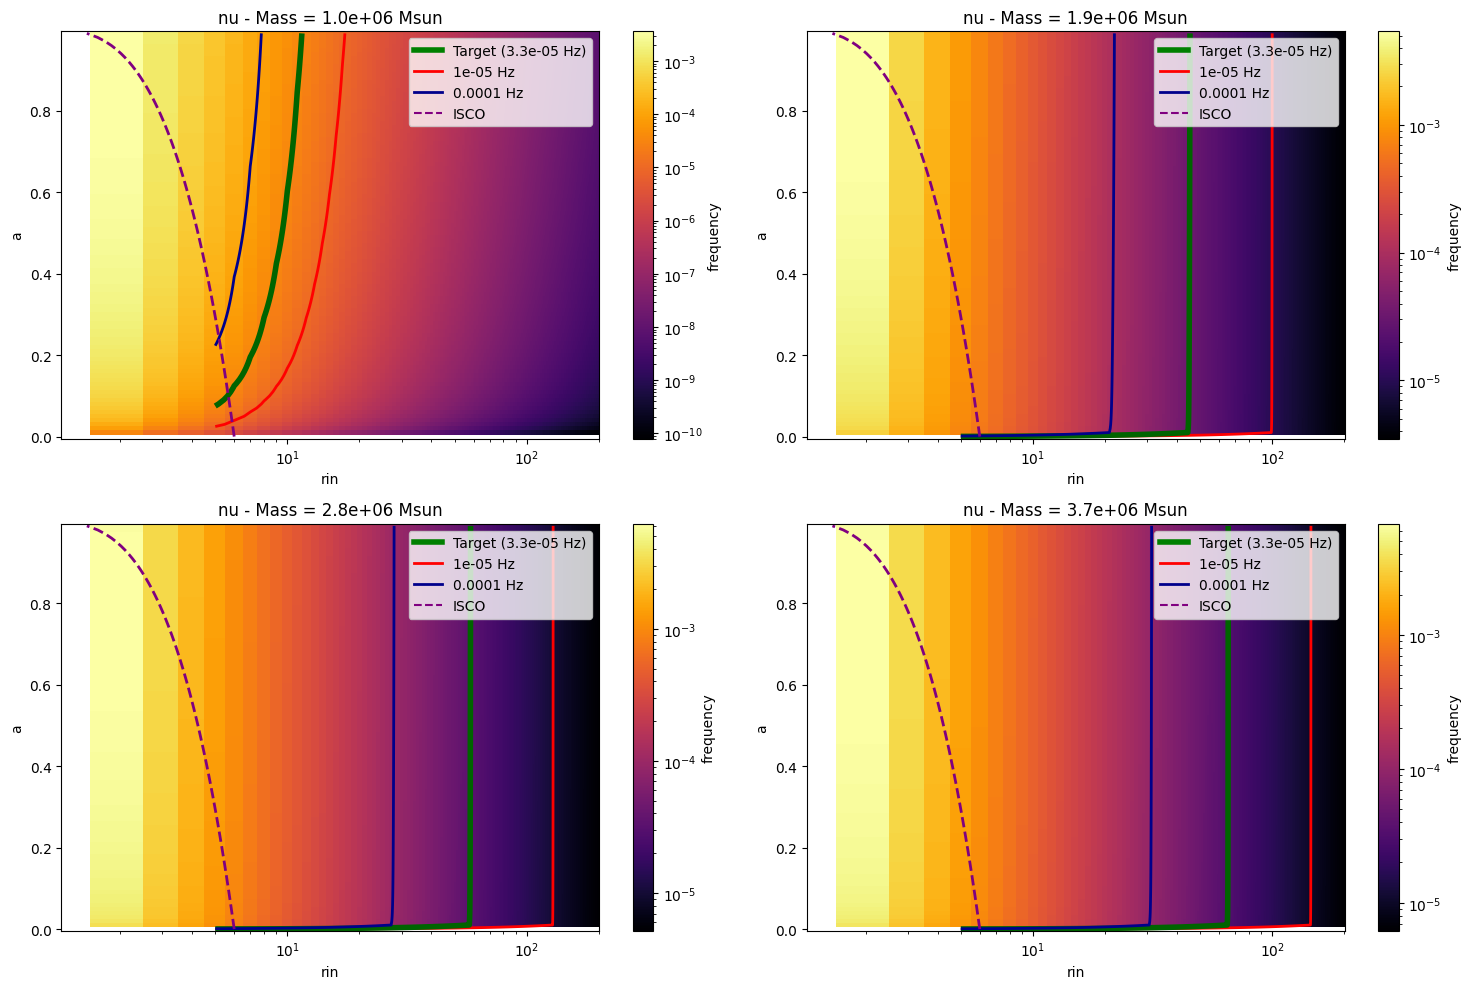

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

idx_values = [0, 1, 2, 3]

for ax, idx in zip(axes, idx_values):
    plt.sca(ax)  # imposta ax come asse corrente
    plot_param_colormap(
        mesh_arrays2,
        labels2,
        freq2,
        x_param="rin",
        y_param="a",
        idx_fix=idx,
        log_x=True,
        title=f"nu - Mass = {M2[0,0,0,0,idx,0]:.1e} Msun",
    )

plt.tight_layout()
plt.show()

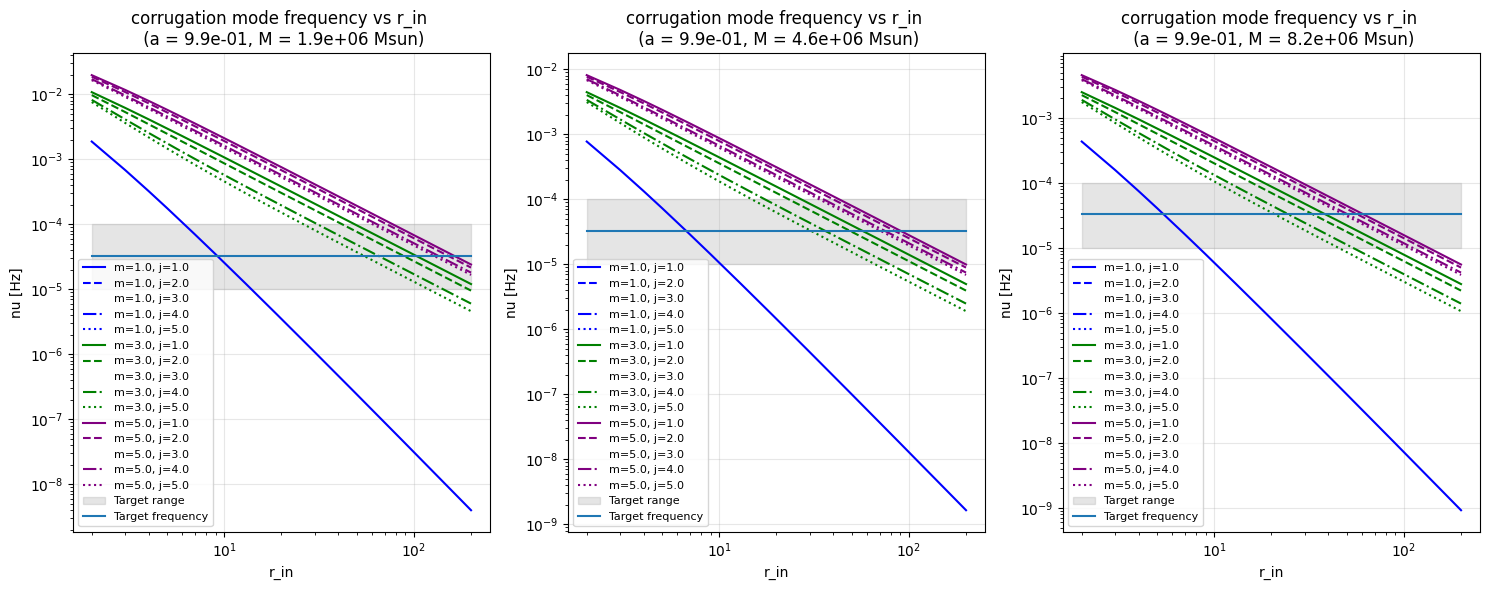

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.flatten()

M_idx = [1, 4, 8]
ia = 99

stiles = ['-', '--', '', '-.', ':']
colors = ["blue", "orange", "green", "red", "purple"]

# Loop over zeta values
for i, iM in enumerate(M_idx):
    for im in (0, 2, 4):
        for ij, jj in enumerate(j):
            r_vals = RIN2[0,0,ia,:,iM,0]
            freq_vals = freq2[im, ij, ia, :, iM, 0]    # vector shape (No,)

            # plot only valid positive frequencies
            mask = np.isfinite(freq_vals) & (freq_vals > 0)
            mask &= (r_vals > r_isco(A2[0,0,ia,0,iM,0]))

            jj = j2[im, ij, ia, 0, iM, 0]
            mm = m2[im, ij, ia, 0, iM, 0]

            label = f"m={mm}, j={jj}"
            axes[i].plot(r_vals[mask], freq_vals[mask], label=label, 
                         linestyle=stiles[ij % len(stiles)],
                         color=colors[im % len(colors)])

    # Target frequency band
    axes[i].fill_between(r_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2,
                    label="Target range")
    axes[i].plot(r_vals, np.ones_like(r_vals)*NU0, label="Target frequency")

    axes[i].set_title(f"corrugation mode frequency vs r_in \n (a = {A2[0, 0, ia, 0, 0, 0]:.1e}, M = {M2[0,0, ia, 0,iM,0]:.1e} Msun)")
    axes[i].set_xlabel("r_in")
    axes[i].set_ylabel("nu [Hz]")
    axes[i].set_yscale("log")
    axes[i].set_xscale("log")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


- come sopra, massa abbassa frequenze
- serve andare a raggi molto grandi (oltre 100 Rg) per trovare match sotto questte condizioni, infatti sopra non avevo visto nessuna compatibilità di fatto
- aumentare spin fa andare sistema a isco più piccole, amplia compatibilità
- m=1, frequuenza non definitia per j diveso da 1